# Анализ пользовательской активности сервиса «Яндекс Книги»

**Автор:** Екатерина Штрейс  
**Дата:** 18 мая 2026 года

## Цель исследования

Проверить, различается ли суммарное время чтения и прослушивания книг у пользователей Москвы и Санкт-Петербурга. Анализ включает контроль качества данных, сравнение распределений и одностороннюю проверку статистической гипотезы для двух независимых выборок.

## Данные

Набор `yandex_knigi_data.csv` содержит агрегированную активность пользователей:

- `city` — город пользователя;
- `puid` — идентификатор пользователя;
- `hours` — суммарное количество часов чтения и прослушивания.

Перед статистической проверкой исключаются пользователи, которые представлены одновременно в двух городах, чтобы сохранить независимость выборок.

## 1. Загрузка и первичный контроль данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ModuleNotFoundError: No module named 'pandas'

In [2]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')

display(data.head())
data.info()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [3]:
print(f'Количество строк: {data.shape[0]}')
print(f'Количество столбцов: {data.shape[1]}')
print(f'Количество полных дубликатов строк: {data.duplicated().sum()}')
print(f'Количество пропусков в данных: {data.isna().sum().sum()}')
print(f'Количество повторов puid: {data["puid"].duplicated().sum()}')

overlap_puids = (
    data.groupby('puid')['city']
    .nunique()
    .loc[lambda x: x > 1]
    .index
)

print(f'Количество пользователей, встречающихся в обоих городах: {len(overlap_puids)}')

display(data['city'].value_counts().to_frame('rows'))
display(data.groupby('city')['puid'].nunique().to_frame('unique_users'))
display(data.groupby('city')['hours'].describe().round(2))

if len(overlap_puids) > 0:
    display(
        data[data['puid'].isin(overlap_puids)]
        .sort_values('puid')
        .head(10)
    )


Количество строк: 8784
Количество столбцов: 4
Количество полных дубликатов строк: 0
Количество пропусков в данных: 0
Количество повторов puid: 244
Количество пользователей, встречающихся в обоих городах: 244


,rows
Москва,6234
Санкт-Петербург,2550


,unique_users
city,
Москва,6234
Санкт-Петербург,2550


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,6234.0,10.88,36.85,0.0,0.06,0.92,5.94,857.21
Санкт-Петербург,2550.0,11.59,39.70,0.0,0.08,0.98,6.51,978.76


,Unnamed: 0,city,puid,hours
35,35,Москва,2637041,10.317371
6247,6247,Санкт-Петербург,2637041,3.883926
134,134,Москва,9979490,32.415573
6274,6274,Санкт-Петербург,9979490,1.302997
145,145,Москва,10597984,42.931506
6279,6279,Санкт-Петербург,10597984,9.041320
150,150,Москва,10815097,9.086655
6283,6283,Санкт-Петербург,10815097,0.323291
187,187,Москва,13626259,21.104167
6300,6300,Санкт-Петербург,13626259,1.648434


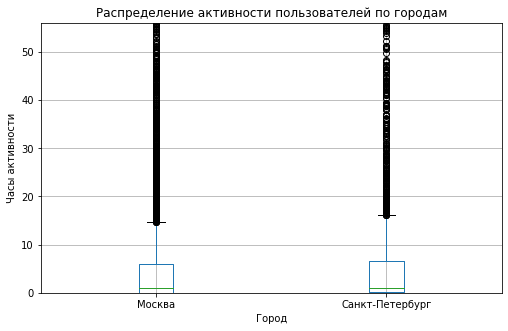

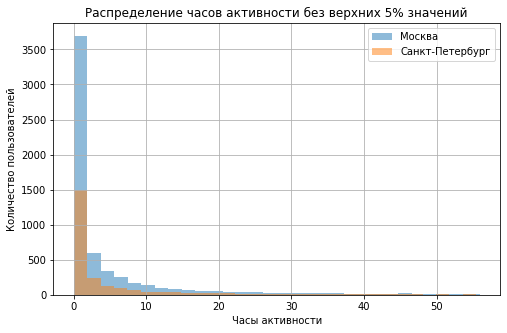

In [4]:
q95 = data['hours'].quantile(0.95)

fig, ax = plt.subplots(figsize=(8, 5))
data.boxplot(column='hours', by='city', ax=ax)
ax.set_ylim(0, q95)
ax.set_title('Распределение активности пользователей по городам')
ax.set_xlabel('Город')
ax.set_ylabel('Часы активности')
fig.suptitle('')
plt.show()

plt.figure(figsize=(8, 5))
for city in data['city'].unique():
    sample = data.loc[data['city'] == city, 'hours']
    plt.hist(sample[sample <= q95], bins=30, alpha=0.5, label=city)

plt.title('Распределение часов активности без верхних 5% значений')
plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True)
plt.show()

## Результаты первичного контроля

В таблице 8 784 строки и четыре столбца. Технический индекс `Unnamed: 0` не используется в анализе. Пропуски отсутствуют, однако часть идентификаторов встречается более одного раза, поэтому перед сравнением городов отдельно проверяется пересечение пользователей.

Распределение активности имеет правый хвост и содержит пользователей с высокой суммарной продолжительностью чтения и прослушивания. Для сравнения групп используются как средние, так и медианные значения.

## 2. Проверка статистической гипотезы

Проверяется предположение о том, что пользователи Санкт-Петербурга в среднем проводят в сервисе больше времени, чем пользователи Москвы.

- **H₀:** средняя активность пользователей Санкт-Петербурга не превышает среднюю активность пользователей Москвы.
- **H₁:** средняя активность пользователей Санкт-Петербурга выше.

Для двух независимых выборок применяется односторонний t-тест Уэлча с уровнем значимости 5%.

In [5]:
alpha = 0.05

# Для двухвыборочного t-теста группы должны быть независимыми.
# Поэтому исключаем пользователей, которые встречаются сразу в двух городах.
analysis_data = data[~data['puid'].isin(overlap_puids)].copy()

moscow_hours = analysis_data.loc[analysis_data['city'] == 'Москва', 'hours']
spb_hours = analysis_data.loc[analysis_data['city'] == 'Санкт-Петербург', 'hours']

summary = (
    analysis_data
    .groupby('city')['hours']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

display(summary)

levene_result = stats.levene(moscow_hours, spb_hours)

# Проверяем гипотезу:
# H0: средняя активность пользователей Санкт-Петербурга не больше, чем в Москве.
# H1: средняя активность пользователей Санкт-Петербурга больше, чем в Москве.
# Используем t-тест Уэлча как более устойчивый вариант двухвыборочного t-теста.
ttest_result = stats.ttest_ind(
    spb_hours,
    moscow_hours,
    equal_var=False,
    alternative='greater'
)

raw_ttest_result = stats.ttest_ind(
    data.loc[data['city'] == 'Санкт-Петербург', 'hours'],
    data.loc[data['city'] == 'Москва', 'hours'],
    equal_var=False,
    alternative='greater'
)

print(f'Удалено пользователей с пересечением городов: {len(overlap_puids)}')
print(f't-статистика: {ttest_result.statistic:.4f}')
print(f'p-value: {ttest_result.pvalue:.4f}')
print(f'p-value без удаления пересечений, для справки: {raw_ttest_result.pvalue:.4f}')

if ttest_result.pvalue < alpha:
    print('Вывод: отвергаем H0. Есть статистически значимые основания считать, что средняя активность пользователей Санкт-Петербурга выше.')
else:
    print('Вывод: не отвергаем H0. Статистически значимых оснований считать, что средняя активность пользователей Санкт-Петербурга выше, нет.')

,count,mean,median,std
city,,,,
Москва,5990,10.85,0.89,36.93
Санкт-Петербург,2306,11.26,0.88,39.83


Удалено пользователей с пересечением городов: 244
t-статистика: 0.4350
p-value: 0.3318
p-value без удаления пересечений, для справки: 0.2182
Вывод: не отвергаем H0. Статистически значимых оснований считать, что средняя активность пользователей Санкт-Петербурга выше, нет.


## Аналитический вывод

После исключения пользователей, представленных сразу в двух городах, в анализ вошли 5 990 пользователей Москвы и 2 306 пользователей Санкт-Петербурга.

Средняя активность составила 10,85 часа в Москве и 11,26 часа в Санкт-Петербурге. Несмотря на наблюдаемую разницу, статистический тест не дал оснований утверждать, что средняя активность пользователей Санкт-Петербурга выше на уровне значимости 5%. Полученное различие может быть связано с естественной вариативностью выборок.